In [5]:
import sys
sys.path.append('../')

import numpy as np
import pickle

from conformal_clustering.utils import ConformalClustering, sample_gmm, label_alignment

from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [6]:
# Core colors
core_hex = {
    2: "#2ECC40",  # green
    0: "#FDFF8D",  # orange
    3: "#64EDFF83",  # blue
    1: "#FF810B",  # red
    4: "#B10DC9",  # purple
}
core_rgb = {k: np.array(mcolors.to_rgb(v), float) for k, v in core_hex.items()}

# Define dark colors for training points
def darken(rgb, factor=0.15):  # 0.15 = 15% darker
    return np.clip(rgb * (1 - factor), 0, 1)

dark_colors = {k: darken(core_rgb[k], 0.15) for k in core_rgb}

def lighten_toward_white(rgb, alpha):
    """alpha in [0,1]: 0 = no change, 1 = white."""
    return (1 - alpha) * rgb + alpha * 1.0

def labels_to_color(labels_like, n_classes=5, base_alpha=0.05):
    """
    - If labels_like is an int -> use that core color.
    - If it's an iterable -> take the mean of the cores in it,
      then 'intensify by number of labels' by moving toward white
      with alpha = base_alpha * (k-1), where k = set size.
      (More labels -> lighter background.)
    """
    # normalize to a Python set of ints
    if isinstance(labels_like, (int, np.integer)):
        S = {int(labels_like)}
    else:
        S = {int(x) for x in labels_like}

    # empty set -> white
    if len(S) == 0:
        return np.array([1.0, 1.0, 1.0], float)

    # mean of the present cores
    mean_rgb = np.mean([core_rgb[i] for i in S], axis=0)

    # intensity control by subset size k
    k = len(S)
    alpha = min(1.0, base_alpha * (k - 1))  # more labels -> lighter
    return lighten_toward_white(mean_rgb, alpha)

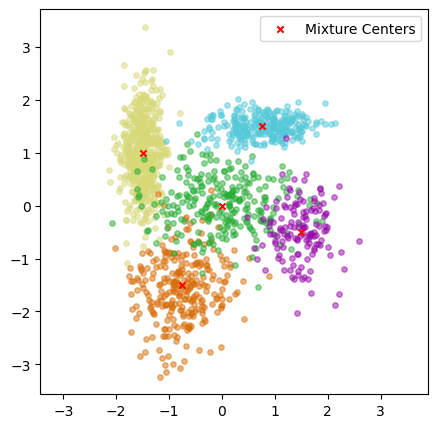

In [7]:
K = 5
p = 2

np.random.seed(7)          # 2

Theta_x = np.linspace(-1.5, 1.5, K)
Theta_y = [1.0, -1.5, 0.0, 1.5, -0.5]

Theta = np.array([Theta_x, Theta_y]).T
vars = np.random.rand(K, p)*0.52        # 0.65
weights = [4,2,2,2,1] # np.random.rand(K)
weights = weights / np.sum(weights)


def generate_data(n_samples=2000):
    labels = np.random.choice(K, size=n_samples, p=weights)
    data = []
    for i in range(n_samples):
        theta = Theta[labels[i]]
        var = vars[labels[i]]
        sample = np.random.multivariate_normal(theta, np.diag(var))
        data.append(sample)
    return np.array(data), labels

n = 1500
X, y = generate_data(n_samples=n)

fig, ax = plt.subplots(figsize=(5, 5))
for label in range(K):
    mask = (y == label)
    ax.scatter(X[mask, 0], X[mask, 1],
                  color=dark_colors[label],
                  s=15, alpha=0.5)
ax.scatter(Theta[:, 0], Theta[:, 1], c='red', marker='x', s=20, label='Mixture Centers')
ax.set_aspect('equal', 'datalim')
ax.legend()
plt.show()

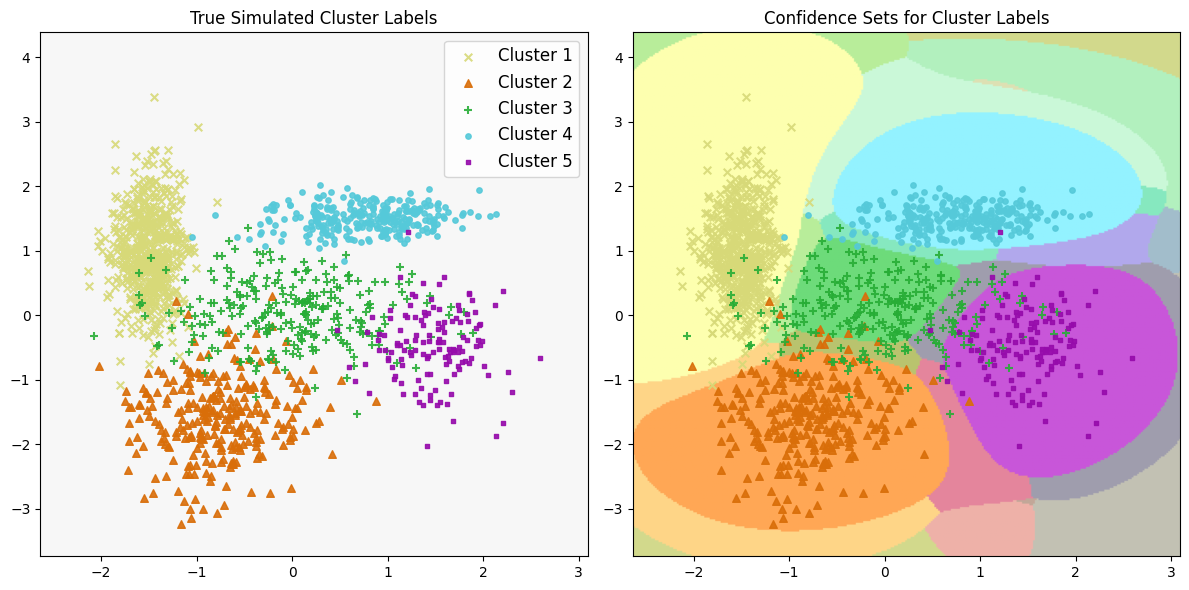

In [8]:
X_tr, y_tr = X[:(n//2)], y[:(n//2)] # training
X_cal, y_cal = X[(n//2):n], y[(n//2):n] # calibration

cc = ConformalClustering(X_tr, X_cal, alpha=0.05)
cc.set_classifier('SVC', random_state=0, probability=True)
cc.fit('GMMS', n_components=K, random_state=2)



# Grid over the 2D plane
x_min = X[:,0].min() - 0.5
x_max = X[:,0].max() + 0.5
y_min = X[:,1].min() - 0.5
y_max = X[:,1].max() + 1
    

res = 300
x_range = np.linspace(x_min, x_max, res)
y_range = np.linspace(y_min, y_max, res)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
grid_points = np.column_stack((X_grid.ravel(), Y_grid.ravel())) # flattened grid points

predictions_boolean = cc.conformal_set(grid_points) # conformal prediction for all grid points
oracle_alignment = label_alignment(y_tr, cc.y_tr, 5) # oracle alignment
color_grid = np.array([labels_to_color(oracle_alignment[np.where(predictions_boolean[i])[0]]) for i in range(predictions_boolean.shape[0])])
color_grid = color_grid.reshape((res, res, 3)) # reshape to grid

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for label in range(K):
    mask = (y == label)
    marker_size = 30
    if label == 0:
        marker = 'x'
    elif label == 1:
        marker = '^'
    elif label == 2:
        marker = '+'
    elif label == 3:
        marker = 'o'
        marker_size = 15
    else:
        marker = 's'
        marker_size = 12
            
    ax[0].scatter(X[mask, 0], 
                  X[mask, 1],
                  color=dark_colors[label],
                  s=marker_size, 
                  alpha=0.9,
                  marker=marker,
                  label=f'Cluster {label+1}')
ax[0].set_facecolor("#F7F7F7")
ax[0].legend(fontsize=12, loc='upper right')
ax[0].set_title('True Simulated Cluster Labels')

ax[1].imshow(
    color_grid, 
    origin='lower', 
    extent=(x_min, x_max, y_min, y_max), 
    aspect='auto', 
    alpha=0.7)
for label in range(K):
    mask = (y == label)
    marker_size = 30
    if label == 0:
        marker = 'x'
    elif label == 1:
        marker = '^'
    elif label == 2:
        marker = '+'
    elif label == 3:
        marker = 'o'
        marker_size = 15
    else:
        marker = 's'
        marker_size = 12

    ax[1].scatter(X[mask, 0], 
                  X[mask, 1],
                  color=dark_colors[label],
                  s=marker_size,
                  alpha=0.9,
                  label=f'Train Label {label}',
                  marker=marker)
ax[1].set_title('Confidence Sets for Cluster Labels')
for i in range(2):
    ax[i].set_xlim(x_min, x_max)
    ax[i].set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('Figures/MotivatingFigures.pdf', bbox_inches='tight')
plt.show()